# Datathon Passos Mágicos — Análise PEDE (2022, 2023 e 2024)

**Objetivo:** responder às 11 perguntas de negócio do Datathon POSTECH com uma leitura clara da evolução dos estudantes e um modelo preventivo de risco de defasagem.

Esta versão preserva os gráficos e as respostas do estudo original, padroniza a identidade visual nas cores da **Passos Mágicos** e atualiza a Pergunta 9 para o modelo vigente: validação temporal, probabilidades calibradas e limiar operacional definido no período de treino.

> Cada pergunta segue a mesma sequência: **pergunta → evidência visual → resposta em linguagem de negócio**. As relações encontradas são observacionais e não comprovam causalidade isoladamente.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

# Identidade visual Passos Mágicos
CORES = {
    'azul_escuro': '#172554',
    'azul': '#3154B8',
    'coral': '#E95D5D',
    'pessego': '#F6C8B8',
    'dourado': '#F2B84B',
    'roxo': '#7465B5',
    'cinza': '#667085',
    'claro': '#F5F7FC',
    'verde': '#4D9B7B',
}
PEDRAS = {
    'Quartzo': '#AEB7C9',
    'Ágata': CORES['azul'],
    'Ametista': CORES['roxo'],
    'Topázio': CORES['dourado'],
}

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#D0D5DD',
    'axes.labelcolor': CORES['azul_escuro'],
    'axes.titlecolor': CORES['azul_escuro'],
    'axes.titleweight': 'bold',
    'axes.grid': True,
    'grid.alpha': 0.18,
    'grid.color': CORES['cinza'],
    'font.size': 11,
    'text.color': CORES['azul_escuro'],
    'xtick.color': CORES['cinza'],
    'ytick.color': CORES['cinza'],
    'legend.frameon': False,
})

def localizar(nome):
    candidatos = [
        Path(nome), Path('upload') / nome, Path('../upload') / nome,
        Path('datathon_melhorado') / nome, Path('../datathon_melhorado') / nome,
        Path('/workspace/scratch/9e22ceca1271/upload') / nome,
        Path('/workspace/scratch/9e22ceca1271/datathon_melhorado') / nome,
    ]
    for candidato in candidatos:
        if candidato.exists():
            return candidato
    encontrados = list(Path.cwd().rglob(nome))
    if encontrados:
        return encontrados[0]
    raise FileNotFoundError(f'Arquivo não encontrado: {nome}')

PATH = localizar('BASE DE DADOS PEDE 2024 - DATATHON.xlsx')
print(f'Base utilizada: {PATH}')


Base utilizada: BASE DE DADOS PEDE 2024 - DATATHON.xlsx


## 1. Carregamento e harmonização dos dados

As três abas têm esquemas de coluna diferentes (nomes de fase, notas, presença de `IPP`, etc.). Construímos uma base única **longitudinal** (`full`), com uma linha por aluno/ano, padronizando nomes de colunas e extraindo o número da fase (`Fase_num`) a partir de rótulos como `"FASE 3"`, `"3A"` ou `"ALFA"`.

In [2]:
def fase_num(x):
    """Extrai o número da fase a partir de rótulos como 'FASE 3', '3A' ou 'ALFA' (=0)."""
    if pd.isna(x):
        return np.nan
    s = str(x).upper().strip()
    if s.startswith('ALFA'):
        return 0
    m = re.search(r'(\d+)', s)
    return int(m.group(1)) if m else np.nan


def load_year(sheet, ano):
    df = pd.read_excel(PATH, sheet_name=sheet)
    out = pd.DataFrame()
    out['RA'] = df['RA']
    out['Ano'] = ano
    out['Fase_num'] = df['Fase'].apply(fase_num)
    out['Turma'] = df.get('Turma')
    out['Genero'] = df['Gênero'].replace({'Menina': 'Feminino', 'Menino': 'Masculino'})
    out['Ano_ingresso'] = df['Ano ingresso']

    inde_col = {2022: 'INDE 22', 2023: 'INDE 2023', 2024: 'INDE 2024'}[ano]
    out['INDE'] = pd.to_numeric(df[inde_col], errors='coerce')

    pedra_col = 'Pedra 22' if ano == 2022 else f'Pedra {ano}'
    out['Pedra'] = df[pedra_col].replace({'Agata': 'Ágata'})
    out.loc[out['Pedra'] == 'INCLUIR', 'Pedra'] = np.nan

    out['IAA'] = df['IAA']
    out['IEG'] = df['IEG']
    out['IPS'] = df['IPS']
    out['IPP'] = df['IPP'] if 'IPP' in df.columns else np.nan   # IPP só existe em 2023/2024
    out['IDA'] = df['IDA']
    out['IAN'] = df['IAN']
    out['IPV'] = df['IPV']
    out['Defasagem'] = df['Defas'] if 'Defas' in df.columns else df['Defasagem']
    out['Atingiu_PV'] = df['Atingiu PV'] if 'Atingiu PV' in df.columns else np.nan  # só 2022
    out['Indicado_bolsa'] = df['Indicado'] if 'Indicado' in df.columns else np.nan  # só 2022

    mat_col = 'Matem' if 'Matem' in df.columns else 'Mat'
    por_col = 'Portug' if 'Portug' in df.columns else 'Por'
    out['Nota_Mat'] = df[mat_col]
    out['Nota_Por'] = df[por_col]
    out['Instituicao'] = df['Instituição de ensino']
    return out


d22 = load_year('PEDE2022', 2022)
d23 = load_year('PEDE2023', 2023)
d24 = load_year('PEDE2024', 2024)
full = pd.concat([d22, d23, d24], ignore_index=True)

def severidade(d):
    if d >= 0:
        return 'Adequado (>=0)'
    if d == -1:
        return 'Moderado (-1 ano)'
    return 'Severo (<=-2 anos)'

full['Sev_defasagem'] = full['Defasagem'].apply(severidade)

print(f"Total de registros: {len(full)}  |  Alunos únicos: {full['RA'].nunique()}")
full.groupby('Ano').size().rename('nº alunos').to_frame()

Total de registros: 3030  |  Alunos únicos: 1661


,nº alunos
Ano,
2022,860
2023,1014
2024,1156


**Limitações importantes dos dados** (impactam o que é possível responder por ano):
- `IPP` só existe nas abas 2023 e 2024 (ausente em 2022) → a pergunta 6 usa apenas 2023/2024.
- `Atingiu PV` (booleano) e `Indicado_bolsa` só existem em 2022 → nos demais anos usamos o **indicador contínuo `IPV`** como proxy do ponto de virada.
- Nem todo aluno aparece nos três anos (entradas/saídas do programa) — para as análises longitudinais (evolução do mesmo aluno) usamos apenas o subconjunto de alunos presentes em anos consecutivos, identificados pelo `RA`.

In [3]:
def pares_longitudinais(full, ano_n, ano_n1, cols):
    """Casa o mesmo aluno (RA) entre dois anos consecutivos e retorna um DataFrame wide."""
    d1 = full[full['Ano'] == ano_n].set_index('RA')
    d2 = full[full['Ano'] == ano_n1].set_index('RA')
    comuns = d1.index.intersection(d2.index)
    out = pd.DataFrame(index=comuns)
    for c in cols:
        out[f'{c}_N'] = d1.loc[comuns, c]
        out[f'{c}_N1'] = d2.loc[comuns, c]
    return out

## Pergunta 1 — Adequação de nível (IAN): perfil de defasagem e evolução

% de alunos por severidade de defasagem:


Sev_defasagem,Adequado (>=0),Moderado (-1 ano),Severo (<=-2 anos)
Ano,,,
2022,30.1,47.7,22.2
2023,45.6,40.2,14.2
2024,53.8,38.1,8.0



IAN médio por ano:


Ano
2022    6.42
2023    7.24
2024    7.68
Name: IAN, dtype: float64

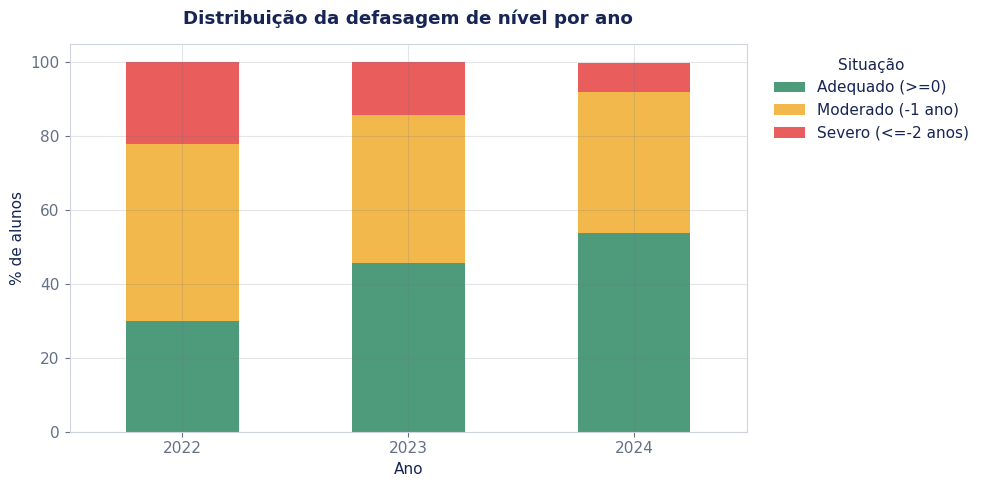

In [4]:
tab_defas = pd.crosstab(full['Ano'], full['Sev_defasagem'], normalize='index').mul(100).round(1)
tab_defas = tab_defas[['Adequado (>=0)', 'Moderado (-1 ano)', 'Severo (<=-2 anos)']]
ian_medio = full.groupby('Ano')['IAN'].mean().round(2)

print('% de alunos por severidade de defasagem:')
display(tab_defas)
print('\nIAN médio por ano:')
display(ian_medio)

ax = tab_defas.plot(
    kind='bar', stacked=True,
    color=[CORES['verde'], CORES['dourado'], CORES['coral']],
    figsize=(10, 5)
)
ax.set_title('Distribuição da defasagem de nível por ano', pad=14)
ax.set_ylabel('% de alunos'); ax.set_xlabel('Ano'); ax.tick_params(axis='x', rotation=0)
ax.legend(title='Situação', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(); plt.show()


**Resposta:** o quadro de defasagem melhora consistentemente: alunos "adequados" (D≥0) saltam de **30,1% (2022) → 45,6% (2023) → 53,8% (2024)**, enquanto a defasagem severa (2+ anos) cai de **22,2% → 14,2% → 8,0%**. O IAN médio acompanha essa tendência (**6,42 → 7,24 → 7,68**). A defasagem moderada (1 ano) permanece o grupo mais estável (≈38–48%), sugerindo que a "última milha" para recolocar o aluno na fase ideal é o principal gargalo remanescente.

## Pergunta 2 — Desempenho acadêmico (IDA): melhora, estagna ou cai?

IDA médio geral por ano:


Ano
2022    6.09
2023    6.66
2024    6.35
Name: IDA, dtype: float64


IDA médio por fase e ano:


Ano,2022,2023,2024
Fase_num,,,
0,7.14,7.42,7.32
1,6.46,6.81,6.79
2,5.41,6.74,6.25
3,5.14,5.75,5.35
4,6.05,6.00,5.88
5,5.87,5.90,6.45
6,6.69,6.81,7.23
7,5.25,7.81,5.81
8,NaN,NaN,8.00


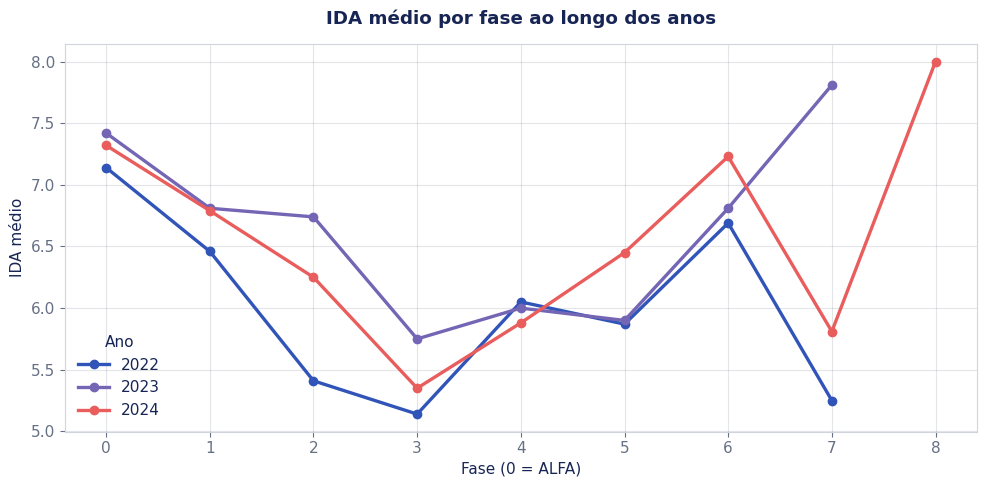

In [5]:
ida_ano = full.groupby('Ano')['IDA'].mean().round(2)
ida_fase = full.pivot_table(index='Fase_num', columns='Ano', values='IDA', aggfunc='mean').round(2)

print('IDA médio geral por ano:'); display(ida_ano)
print('\nIDA médio por fase e ano:'); display(ida_fase)

ax = ida_fase.plot(marker='o', linewidth=2.4, markersize=6,
                   color=[CORES['azul'], CORES['roxo'], CORES['coral']], figsize=(10, 5))
ax.set_title('IDA médio por fase ao longo dos anos', pad=14)
ax.set_xlabel('Fase (0 = ALFA)'); ax.set_ylabel('IDA médio'); ax.legend(title='Ano')
plt.tight_layout(); plt.show()


**Resposta:** no agregado, o IDA médio oscila sem tendência clara: **6,09 (2022) → 6,66 (2023) → 6,35 (2024)** — uma leve melhora seguida de recuo, portanto **estagnado/instável**, não uma trajetória de melhora sustentada. Ao abrir por fase, o padrão é heterogêneo: fases iniciais (0–1, ALFA/Fase 1) mantêm IDA relativamente estável e mais alto (~6,5–7,4), enquanto fases intermediárias (2–4, tipicamente 5º–8º ano) ficam consistentemente mais baixas (~5,1–6,7), indicando que a perda de desempenho acadêmico se concentra na transição para os anos finais do fundamental.

## Pergunta 3 — Engajamento (IEG) x Desempenho (IDA) e Ponto de Virada (IPV)

,"corr(IEG, IDA)","corr(IEG, IPV)"
Ano,,
2022,0.564,0.589
2023,0.461,0.449
2024,0.538,0.535


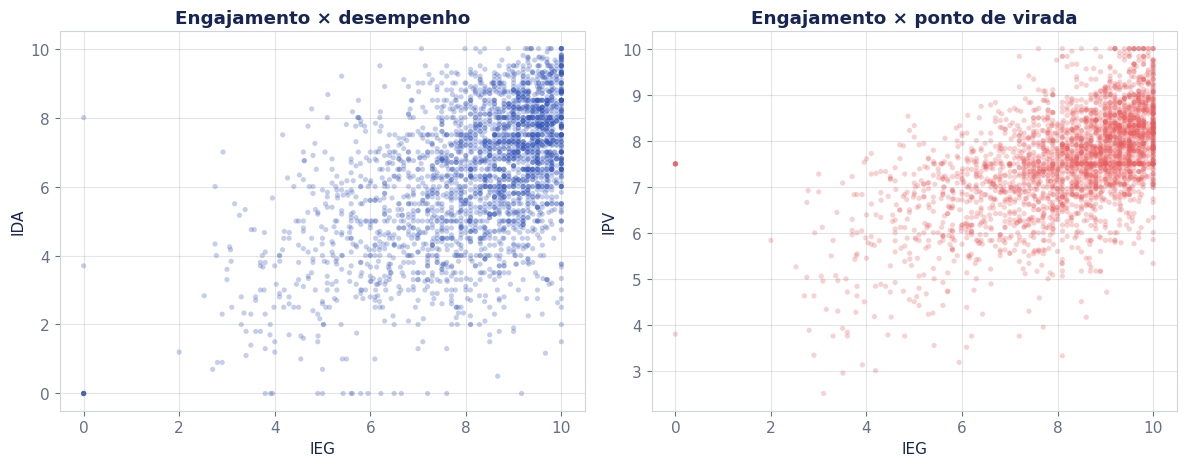

In [6]:
corr_ieg = full.groupby('Ano').apply(lambda d: pd.Series({
    'corr(IEG, IDA)': d['IEG'].corr(d['IDA']),
    'corr(IEG, IPV)': d['IEG'].corr(d['IPV'])
})).round(3)
display(corr_ieg)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.8))
ax[0].scatter(full['IEG'], full['IDA'], s=14, alpha=0.28, color=CORES['azul'], edgecolors='none')
ax[0].set_xlabel('IEG'); ax[0].set_ylabel('IDA'); ax[0].set_title('Engajamento × desempenho')
ax[1].scatter(full['IEG'], full['IPV'], s=14, alpha=0.28, color=CORES['coral'], edgecolors='none')
ax[1].set_xlabel('IEG'); ax[1].set_ylabel('IPV'); ax[1].set_title('Engajamento × ponto de virada')
plt.tight_layout(); plt.show()


**Resposta:** sim, há relação direta e consistente nos três anos. A correlação de Pearson entre IEG e IDA varia de **0,46 a 0,56**, e entre IEG e IPV de **0,45 a 0,59** — força **moderada a moderada-forte**, estável ao longo do tempo. Engajamento não é apenas um indicador de "comportamento": ele se traduz em desempenho acadêmico e em progresso no ponto de virada, reforçando que ações de estímulo ao engajamento (presença, entrega de tarefas, atividades) têm efeito prático mensurável nos outros dois indicadores.

## Pergunta 4 — Autoavaliação (IAA) é coerente com desempenho (IDA) e engajamento (IEG)?

,"corr(IAA, IDA)","corr(IAA, IEG)"
Ano,,
2022,0.209,0.323
2023,0.105,0.170
2024,0.220,0.230



Gap médio (IAA - IDA) por Pedra:


Pedra
Quartzo     2.29
Ágata       1.97
Ametista    1.51
Topázio     0.84
Name: gap_confianca, dtype: float64

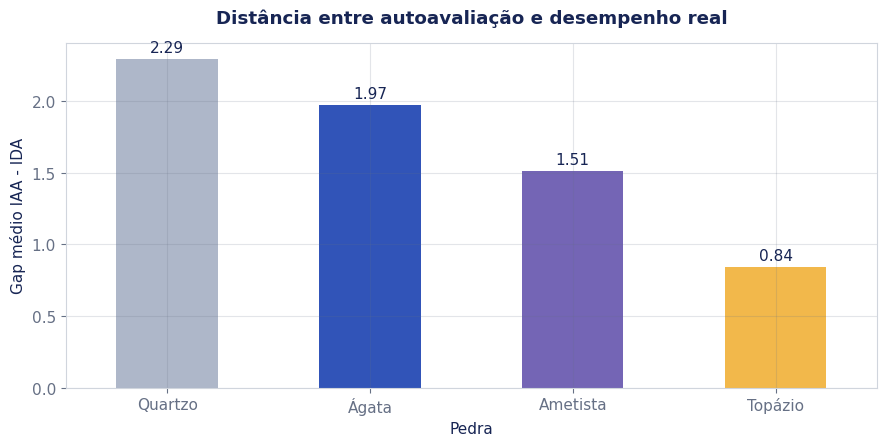

In [7]:
corr_iaa = full.groupby('Ano').apply(lambda d: pd.Series({
    'corr(IAA, IDA)': d['IAA'].corr(d['IDA']),
    'corr(IAA, IEG)': d['IAA'].corr(d['IEG'])
})).round(3)
display(corr_iaa)

full['gap_confianca'] = full['IAA'] - full['IDA']
ordem_pedras = ['Quartzo', 'Ágata', 'Ametista', 'Topázio']
gap_pedra = full.groupby('Pedra')['gap_confianca'].mean().reindex(ordem_pedras).round(2)
print('\nGap médio (IAA - IDA) por Pedra:')
display(gap_pedra)

ax = gap_pedra.plot(kind='bar', color=[PEDRAS[p] for p in ordem_pedras], figsize=(9, 4.6))
ax.set_title('Distância entre autoavaliação e desempenho real', pad=14)
ax.set_xlabel('Pedra'); ax.set_ylabel('Gap médio IAA - IDA'); ax.tick_params(axis='x', rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, color=CORES['azul_escuro'])
plt.tight_layout(); plt.show()


**Resposta:** a coerência é **baixa**. As correlações entre IAA e IDA (0,10–0,22) e entre IAA e IEG (0,17–0,32) são fracas em todos os anos — a autopercepção do aluno explica pouco da variação em desempenho real ou engajamento observado. O gap (IAA − IDA) é positivo em todas as pedras e **maior justamente nos alunos de menor desempenho** (Quartzo: +2,29; Ágata: +1,97) e menor nos de melhor desempenho (Topázio: +0,84) — um padrão clássico de excesso de confiança inversamente proporcional ao desempenho, que sinaliza a necessidade de calibrar a autoavaliação com feedback mais direto, especialmente nas fases de maior dificuldade.

## Pergunta 5 — Padrões psicossociais (IPS) antecedem quedas de desempenho/engajamento?

Correlação IPS no ano N com variação no ano seguinte:
corr(IPS_N, delta_IDA) = 0.12
corr(IPS_N, delta_IEG) = 0.161


,delta_IDA,delta_IEG
Demais alunos,-0.078,-0.285
IPS baixo,-0.627,-0.824


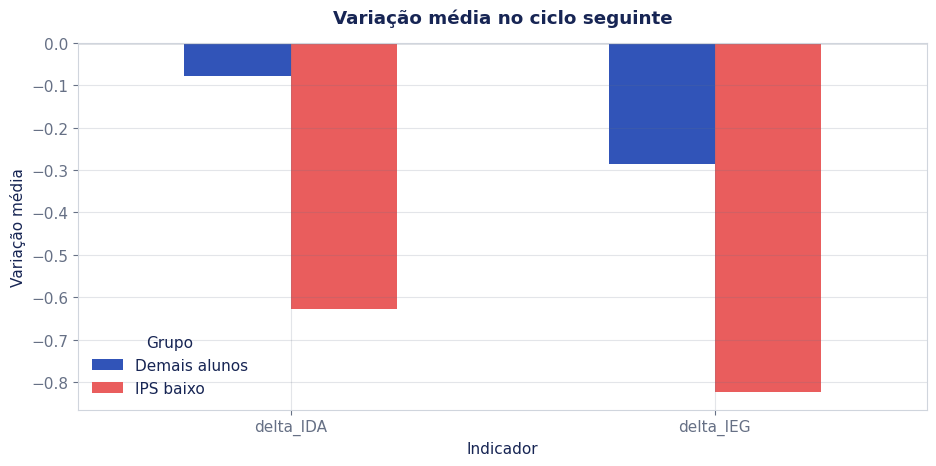

In [8]:
cols = ['IPS','IDA','IEG']
pares = pd.concat([
    pares_longitudinais(full, 2022, 2023, cols),
    pares_longitudinais(full, 2023, 2024, cols)
])
pares['delta_IDA'] = pares['IDA_N1'] - pares['IDA_N']
pares['delta_IEG'] = pares['IEG_N1'] - pares['IEG_N']

print('Correlação IPS no ano N com variação no ano seguinte:')
print('corr(IPS_N, delta_IDA) =', round(pares['IPS_N'].corr(pares['delta_IDA']), 3))
print('corr(IPS_N, delta_IEG) =', round(pares['IPS_N'].corr(pares['delta_IEG']), 3))

pares['IPS_baixo (1º quartil)'] = pares['IPS_N'] < pares['IPS_N'].quantile(0.25)
resumo = pares.groupby('IPS_baixo (1º quartil)')[['delta_IDA','delta_IEG']].mean().round(3)
resumo.index = ['Demais alunos', 'IPS baixo']
display(resumo)

ax = resumo.T.plot(kind='bar', color=[CORES['azul'], CORES['coral']], figsize=(9.5, 4.8))
ax.axhline(0, color=CORES['cinza'], linewidth=1)
ax.set_title('Variação média no ciclo seguinte', pad=14)
ax.set_ylabel('Variação média'); ax.set_xlabel('Indicador'); ax.tick_params(axis='x', rotation=0)
ax.legend(title='Grupo')
plt.tight_layout(); plt.show()


**Resposta:** sim — IPS baixo antecede piora relativa. Alunos no **1º quartil de IPS** no ano N apresentam, no ano seguinte, queda muito mais acentuada de IDA (**−0,63** vs. **−0,08** nos demais) e de IEG (**−0,82** vs. **−0,29**). As correlações diretas (IPS × Δ desempenho) são fracas isoladamente (0,12–0,16), mas o corte por quartil revela um efeito de limiar: **IPS baixo é um sinal de alerta precoce (early warning)** para queda de desempenho e engajamento no ano seguinte, útil como gatilho de intervenção psicossocial preventiva.

## Pergunta 6 — Avaliações psicopedagógicas (IPP) confirmam a defasagem do IAN?

corr(IPP, IAN) = 0.123
corr(IPP, Defasagem) = 0.182

IPP médio por severidade de defasagem (2023-2024):


Sev_defasagem
Adequado (>=0)        7.68
Moderado (-1 ano)     7.55
Severo (<=-2 anos)    7.11
Name: IPP, dtype: float64

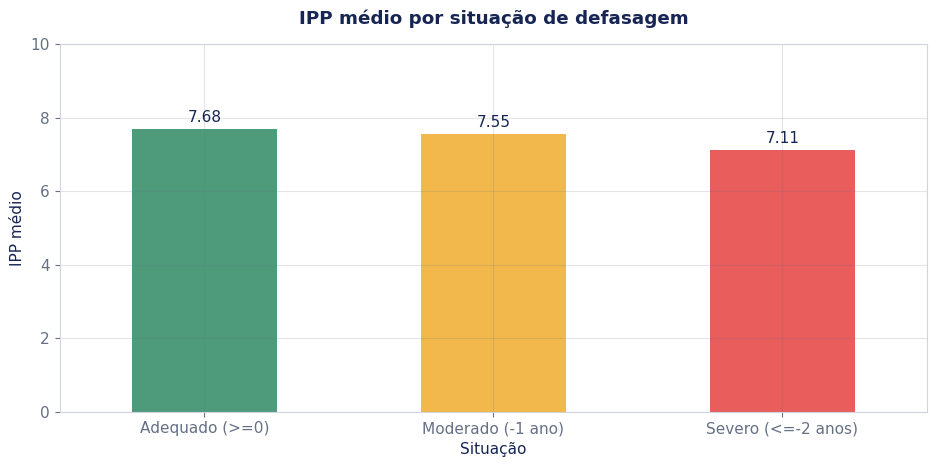

In [9]:
sub = full[full['Ano'].isin([2023, 2024])].copy()
print('corr(IPP, IAN) =', round(sub['IPP'].corr(sub['IAN']), 3))
print('corr(IPP, Defasagem) =', round(sub['IPP'].corr(sub['Defasagem']), 3))

ordem_sev = ['Adequado (>=0)', 'Moderado (-1 ano)', 'Severo (<=-2 anos)']
ipp_sev = sub.groupby('Sev_defasagem')['IPP'].mean().reindex(ordem_sev).round(2)
print('\nIPP médio por severidade de defasagem (2023-2024):')
display(ipp_sev)

ax = ipp_sev.plot(kind='bar', color=[CORES['verde'], CORES['dourado'], CORES['coral']], figsize=(9.5, 4.8))
ax.set_title('IPP médio por situação de defasagem', pad=14)
ax.set_xlabel('Situação'); ax.set_ylabel('IPP médio'); ax.tick_params(axis='x', rotation=0)
ax.set_ylim(0, 10)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, color=CORES['azul_escuro'])
plt.tight_layout(); plt.show()


**Resposta:** há **confirmação direcional, mas fraca em magnitude**. IPP e IAN são positivamente correlacionados (0,12) e o IPP médio cai de forma monotônica com a severidade da defasagem: **7,68 (adequado) → 7,55 (moderado) → 7,11 (severo)**. Ou seja, quanto mais defasado o aluno está em relação à fase ideal, pior tende a ser sua avaliação psicopedagógica — as duas métricas apontam na mesma direção, mas a correlação fraca indica que **IPP e IAN capturam dimensões parcialmente distintas** (uma é estrutural/etária, a outra é qualitativa) e devem ser lidas em conjunto, não como substitutas uma da outra.

## Pergunta 7 — O que mais influencia o Ponto de Virada (IPV)?

Correlação de cada indicador com IPV:


IPP    0.607
IEG    0.558
IDA    0.557
IAN    0.149
IAA    0.063
IPS   -0.049
Name: IPV, dtype: float64

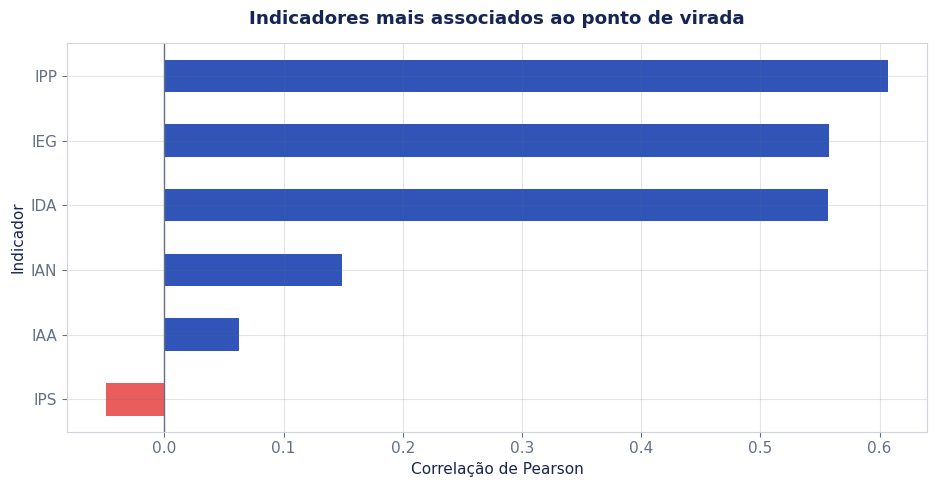

In [10]:
corr_ipv = full[['IAA','IEG','IPS','IPP','IAN','IDA','IPV']].corr()['IPV'].drop('IPV').sort_values().round(3)
print('Correlação de cada indicador com IPV:')
display(corr_ipv.sort_values(ascending=False))

cores_ipv = [CORES['coral'] if v < 0 else CORES['azul'] for v in corr_ipv.values]
ax = corr_ipv.plot(kind='barh', color=cores_ipv, figsize=(9.5, 5))
ax.axvline(0, color=CORES['cinza'], linewidth=1)
ax.set_title('Indicadores mais associados ao ponto de virada', pad=14)
ax.set_xlabel('Correlação de Pearson'); ax.set_ylabel('Indicador')
plt.tight_layout(); plt.show()


**Resposta:** os indicadores **acadêmicos e de engajamento dominam** o Ponto de Virada: **IPP (0,61)**, **IEG (0,56)** e **IDA (0,56)** têm as correlações mais fortes com IPV, seguidos de longe por IAN (0,15). **IAA (0,06) e IPS (−0,05) praticamente não se relacionam** com IPV. Isso indica que o ponto de virada é impulsionado principalmente por comportamentos observáveis e mensuráveis pela equipe pedagógica (engajamento, aprendizagem, avaliação psicopedagógica) — não pela autopercepção do aluno nem, isoladamente, pelo aspecto psicossocial, que age mais como fator antecedente indireto (ver Pergunta 5) do que como componente direto do IPV.

## Pergunta 8 — Quais combinações de indicadores mais elevam o INDE?

R² do modelo linear (N=1985): 0.823



IDA    0.452
IEG    0.386
IPS    0.231
IPP    0.213
dtype: float64

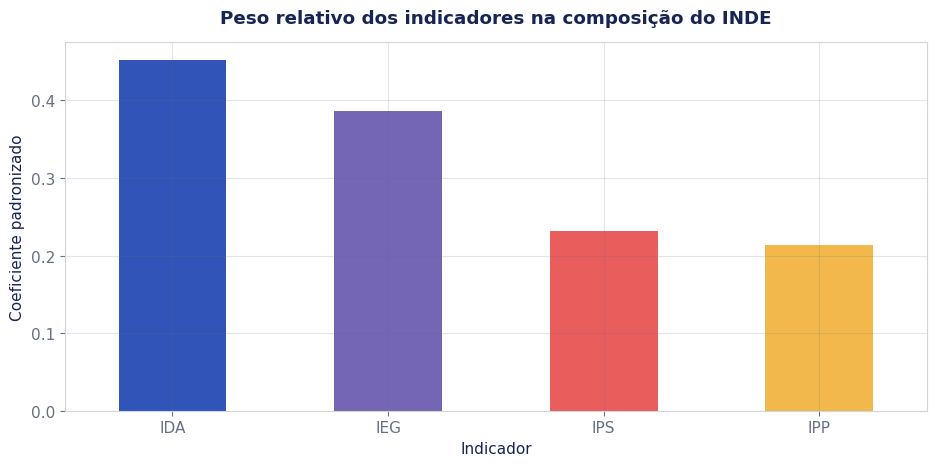

In [11]:
from sklearn.linear_model import LinearRegression

cols = ['IDA','IEG','IPS','IPP']
sub = full.dropna(subset=cols + ['INDE'])
X = (sub[cols] - sub[cols].mean()) / sub[cols].std()
y = sub['INDE']

lr = LinearRegression().fit(X, y)
pesos = pd.Series(lr.coef_, index=cols).sort_values(ascending=False).round(3)
print(f'R² do modelo linear (N={len(sub)}): {lr.score(X, y):.3f}\n')
display(pesos)

ax = pesos.plot(kind='bar', color=[CORES['azul'], CORES['roxo'], CORES['coral'], CORES['dourado']], figsize=(9.5, 4.8))
ax.set_title('Peso relativo dos indicadores na composição do INDE', pad=14)
ax.set_ylabel('Coeficiente padronizado'); ax.set_xlabel('Indicador'); ax.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()


**Resposta:** um modelo linear com IDA, IEG, IPS e IPP explica **82,3% da variação do INDE** (R²=0,823, N=1.985). A combinação que mais eleva a nota global é, em ordem de peso: **IDA (0,45) > IEG (0,39) > IPS (0,23) ≈ IPP (0,21)**. Ou seja, desempenho acadêmico e engajamento têm impacto quase duas vezes maior que os componentes psicossocial/psicopedagógico — mas os quatro juntos, e não um isoladamente, é que sustentam um INDE alto, confirmando o caráter **multidimensional** do índice por desenho.

## Pergunta 9 — Quais padrões permitem prever risco de defasagem?

**Definição atual do alvo:** estimar a probabilidade de o aluno **apresentar defasagem no próximo ciclo**, isto é, `Defasagem_N1 ≤ -1`. O modelo não afirma que o estudante necessariamente “entrou” em defasagem, pois parte dos casos positivos já estava defasada e permaneceu nessa condição.

### Como o modelo atual foi validado

- **Treino:** dados de 2022 para prever 2023.
- **Teste final:** dados de 2023 para prever 2024.
- **Probabilidade calibrada:** a pontuação de risco fica mais adequada para priorização.
- **Limiar operacional:** 0,4934, escolhido apenas com dados do treino.
- **Comparações:** modelo completo, modelo acionável sem IAN/Defasagem e baseline de persistência.

Essa separação temporal representa melhor o uso real e evita misturar passado e futuro na avaliação.


In [12]:
import json

METADATA_PATH = localizar('model_risco_defasagem.metadata.json')
with open(METADATA_PATH, encoding='utf-8') as arquivo:
    metadata_modelo = json.load(arquivo)

metricas = metadata_modelo['metrics']['temporal_holdout']
comparacao = pd.DataFrame(metadata_modelo['metrics']['model_comparison']).T
comparacao = comparacao[['roc_auc', 'pr_auc', 'precision', 'recall', 'f1', 'brier']].round(3)

print('Período de treino:', metadata_modelo['metrics']['train_period'])
print('Período de teste:', metadata_modelo['metrics']['test_period'])
print('Amostras de treino:', metadata_modelo['metrics']['n_train'])
print('Amostras de teste:', metadata_modelo['metrics']['n_test'])
print('Limiar operacional:', metadata_modelo['threshold'])
display(comparacao.rename(index={
    'complete': 'Modelo completo',
    'actionable': 'Modelo acionável',
    'baseline_persistence': 'Baseline de persistência'
}))


Período de treino: 2022->2023
Período de teste: 2023->2024
Amostras de treino: 600
Amostras de teste: 765
Limiar operacional: 0.4934


,roc_auc,pr_auc,precision,recall,f1,brier
Modelo completo,0.8484,0.79,0.6356,0.776,0.6988,0.1719
Modelo acionável,0.8084,0.7464,0.624,0.7922,0.6981,0.2137
baseline_prior,0.5,0.4026,0.4026,1.0,0.5741,0.2835
Baseline de persistência,0.6765,0.5222,0.5671,0.7273,0.6373,0.3333


### Resultado do teste temporal

O teste abaixo usa somente o período mais recente, **2023 para prever 2024**, que ficou completamente separado do treinamento.


,Resultado
ROC-AUC,0.848
PR-AUC,0.790
Precisão,0.636
Recall,0.776
F1-score,0.699
Acurácia,0.731
Brier,0.172


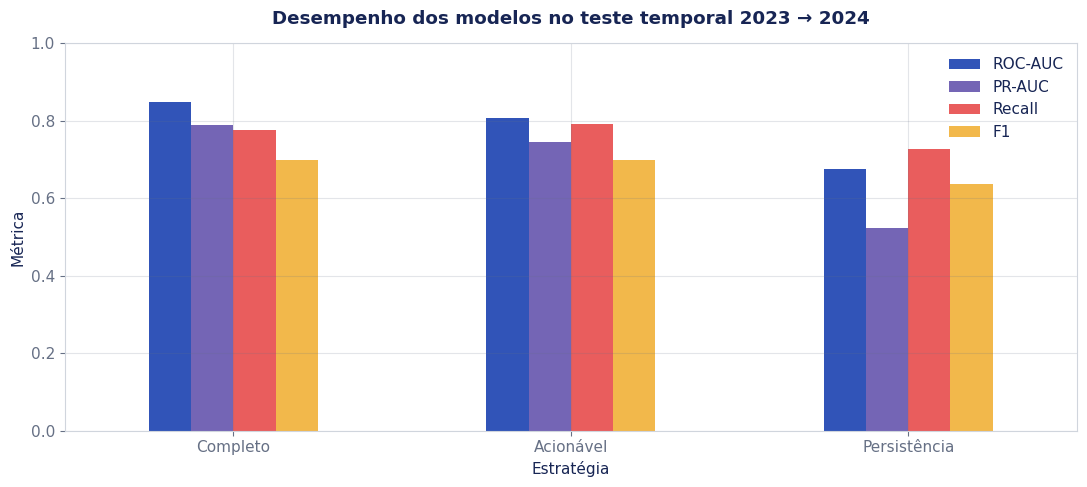

In [13]:
resumo_modelo = pd.Series({
    'ROC-AUC': metricas['roc_auc'],
    'PR-AUC': metricas['pr_auc'],
    'Precisão': metricas['precision'],
    'Recall': metricas['recall'],
    'F1-score': metricas['f1'],
    'Acurácia': metricas['accuracy'],
    'Brier': metricas['brier'],
}).round(3)
display(resumo_modelo.to_frame('Resultado'))

comparacao_plot = comparacao.loc[['complete', 'actionable', 'baseline_persistence'], ['roc_auc', 'pr_auc', 'recall', 'f1']].copy()
comparacao_plot.index = ['Completo', 'Acionável', 'Persistência']
ax = comparacao_plot.plot(
    kind='bar', figsize=(11, 5),
    color=[CORES['azul'], CORES['roxo'], CORES['coral'], CORES['dourado']]
)
ax.set_title('Desempenho dos modelos no teste temporal 2023 → 2024', pad=14)
ax.set_ylabel('Métrica'); ax.set_xlabel('Estratégia'); ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=0); ax.legend(['ROC-AUC', 'PR-AUC', 'Recall', 'F1'])
plt.tight_layout(); plt.show()


### Matriz de confusão e leitura operacional


,Previsto: sem risco,Previsto: em risco
Real: sem risco,320,137
Real: em risco,69,239


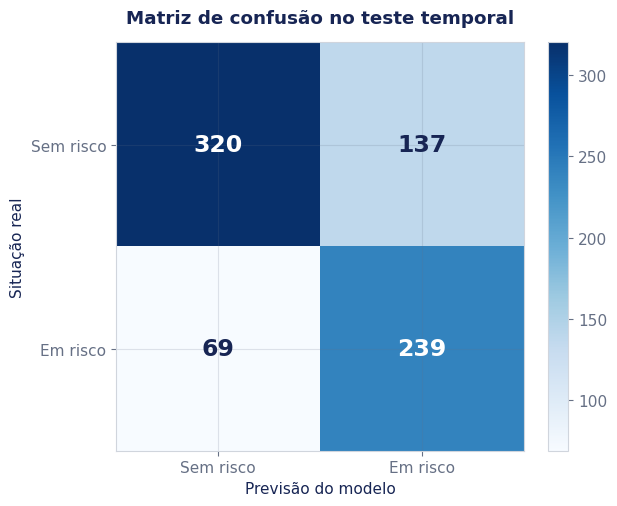

In [14]:
cm = np.array(metricas['confusion_matrix'])
cm_df = pd.DataFrame(cm, index=['Real: sem risco', 'Real: em risco'],
                     columns=['Previsto: sem risco', 'Previsto: em risco'])
display(cm_df)

fig, ax = plt.subplots(figsize=(6.8, 5.2))
imagem = ax.imshow(cm, cmap='Blues')
for (i, j), valor in np.ndenumerate(cm):
    ax.text(j, i, f'{valor}', ha='center', va='center', fontsize=17,
            color='white' if valor > cm.max()/2 else CORES['azul_escuro'], fontweight='bold')
ax.set_xticks([0, 1], ['Sem risco', 'Em risco'])
ax.set_yticks([0, 1], ['Sem risco', 'Em risco'])
ax.set_xlabel('Previsão do modelo'); ax.set_ylabel('Situação real')
ax.set_title('Matriz de confusão no teste temporal', pad=14)
plt.colorbar(imagem, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()


### Faixas de priorização usadas no Streamlit

As faixas não são notas escolares. Elas servem para organizar a fila de acompanhamento e sempre precisam de avaliação humana.


,Limite superior / início da prioridade
Acompanhamento de rotina,0.2467
Monitoramento preventivo,0.4934
Intervenção prioritária,1.0000


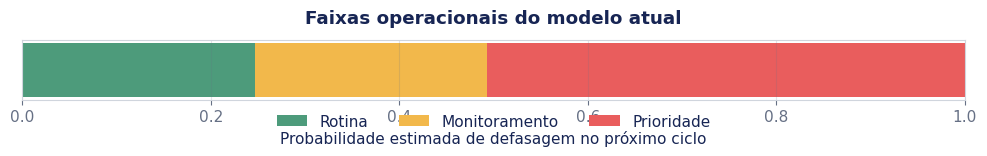

In [15]:
faixas = pd.Series({
    'Acompanhamento de rotina': metadata_modelo['risk_bands']['low_max'],
    'Monitoramento preventivo': metadata_modelo['risk_bands']['priority_min'],
    'Intervenção prioritária': 1.0,
})
display(faixas.to_frame('Limite superior / início da prioridade').round(4))

fig, ax = plt.subplots(figsize=(10, 2.6))
limite_baixo = metadata_modelo['risk_bands']['low_max']
limite_prioridade = metadata_modelo['risk_bands']['priority_min']
ax.barh([0], [limite_baixo], left=0, color=CORES['verde'], label='Rotina')
ax.barh([0], [limite_prioridade-limite_baixo], left=limite_baixo, color=CORES['dourado'], label='Monitoramento')
ax.barh([0], [1-limite_prioridade], left=limite_prioridade, color=CORES['coral'], label='Prioridade')
ax.set_xlim(0, 1); ax.set_yticks([]); ax.set_xlabel('Probabilidade estimada de defasagem no próximo ciclo')
ax.set_title('Faixas operacionais do modelo atual', pad=12)
ax.legend(ncol=3, loc='lower center', bbox_to_anchor=(0.5, -0.72))
plt.tight_layout(); plt.show()


**Resposta:** no teste temporal de 2023 para 2024, o modelo completo alcança **ROC-AUC de 0,848**, **PR-AUC de 0,790**, **recall de 77,6%** e **F1 de 0,699**. Em termos práticos, ele identifica aproximadamente 8 em cada 10 estudantes que realmente apresentarão defasagem no ciclo seguinte, embora gere alertas adicionais que precisam ser avaliados pela equipe.

O modelo completo supera o baseline de persistência (**ROC-AUC 0,677**) e o modelo acionável sem IAN e Defasagem (**ROC-AUC 0,808**). Isso mostra que a situação atual do aluno ainda tem forte poder preditivo, mas os indicadores acadêmicos, de engajamento e psicossociais também acrescentam informação relevante.

O resultado deve ser usado como **apoio à priorização**, nunca como decisão automática. A equipe pedagógica continua responsável por interpretar contexto, histórico e disponibilidade de intervenção.


## Pergunta 10 — Efetividade do programa por fase (Pedra)

INDE médio por Pedra e ano:


Ano,2022,2023,2024
Pedra,,,
Quartzo,5.24,5.55,5.40
Ágata,6.61,6.57,6.60
Ametista,7.53,7.51,7.53
Topázio,8.37,8.44,8.47



% de alunos por Pedra e ano:


Ano,2022,2023,2024
Pedra,,,
Quartzo,15.3,7.7,10.6
Ágata,29.1,26.4,21.3
Ametista,40.5,40.9,37.1
Topázio,15.1,24.9,30.9



Alunos com trajetória completa 2022-2024: 434
INDE médio na trajetória: {'INDE22': 7.38, 'INDE23': 7.35, 'INDE24': 7.38}
% que melhorou INDE de 2022 para 2024: 55.3%


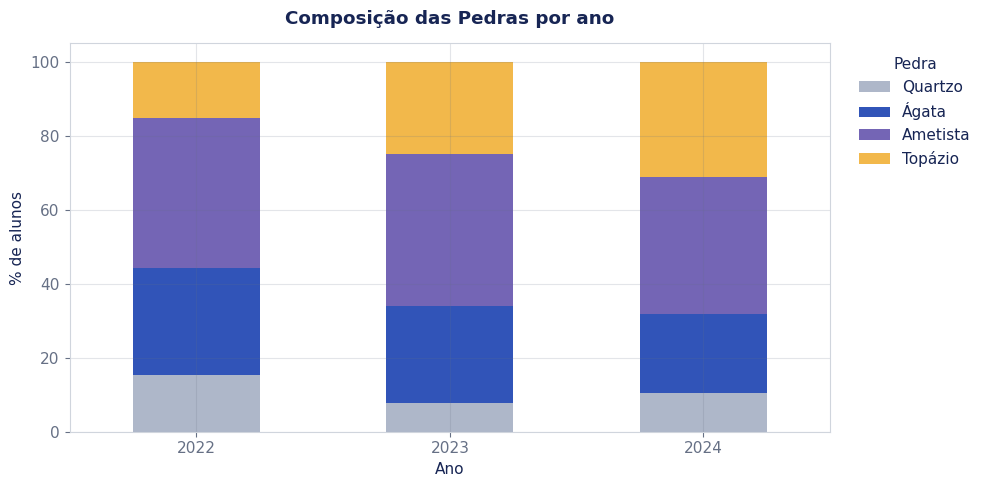

In [16]:
order = ['Quartzo','Ágata','Ametista','Topázio']
inde_pedra = full.pivot_table(index='Pedra', columns='Ano', values='INDE', aggfunc='mean').reindex(order).round(2)
dist_pedra = pd.crosstab(full['Pedra'], full['Ano'], normalize='columns').reindex(order).mul(100).round(1)

print('INDE médio por Pedra e ano:'); display(inde_pedra)
print('\n% de alunos por Pedra e ano:'); display(dist_pedra)

d22 = full[full['Ano']==2022].set_index('RA')
d23 = full[full['Ano']==2023].set_index('RA')
d24 = full[full['Ano']==2024].set_index('RA')
comuns = d22.index.intersection(d23.index).intersection(d24.index)
traj = pd.DataFrame({
    'INDE22': d22.loc[comuns,'INDE'], 'INDE23': d23.loc[comuns,'INDE'], 'INDE24': d24.loc[comuns,'INDE']
}).dropna()
print(f'\nAlunos com trajetória completa 2022-2024: {len(traj)}')
print('INDE médio na trajetória:', traj.mean().round(2).to_dict())
print(f"% que melhorou INDE de 2022 para 2024: {(traj['INDE24']>traj['INDE22']).mean():.1%}")

ax = dist_pedra.T.plot(kind='bar', stacked=True, color=[PEDRAS[p] for p in order], figsize=(10, 5))
ax.set_title('Composição das Pedras por ano', pad=14)
ax.set_ylabel('% de alunos'); ax.set_xlabel('Ano'); ax.tick_params(axis='x', rotation=0)
ax.legend(title='Pedra', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(); plt.show()


**Resposta:** o INDE médio **dentro de cada Pedra é estável ao longo dos anos** (ex.: Topázio 8,37→8,44→8,47; Ametista ~7,5 nos três anos) — cada faixa mantém sua identidade de desempenho, o que valida a consistência da régua de classificação. O sinal mais forte de efetividade está na **migração de composição**: Topázio cresce de **15,1% → 24,9% → 29,9%** dos alunos, enquanto Quartzo cai de **15,3% → 7,7% → 10,6%**. Entre os 434 alunos com trajetória completa nos 3 anos, **55,3% aumentaram seu INDE** de 2022 para 2024 (INDE médio quase estável: 7,38→7,35→7,38, refletindo que grande parte da base já entra em níveis elevados). Em conjunto, os dados **confirmam impacto real do programa**, mais visível no deslocamento de alunos para faixas superiores do que numa alta homogênea do INDE médio geral.

## Pergunta 11 — Insights adicionais

INDE médio por gênero e ano:


Ano,2022,2023,2024
Genero,,,
Feminino,7.09,7.41,7.48
Masculino,6.97,7.27,7.30



Retenção:


,Taxa
2022 → 2023,0.698
2023 → 2024,0.754



Participação de novos alunos:


,Taxa
Novos em 2023,0.408
Novos em 2024,0.338



INDE médio por indicação de bolsa em 2022:


Indicado_bolsa
Não    6.97
Sim    7.41
Name: INDE, dtype: float64

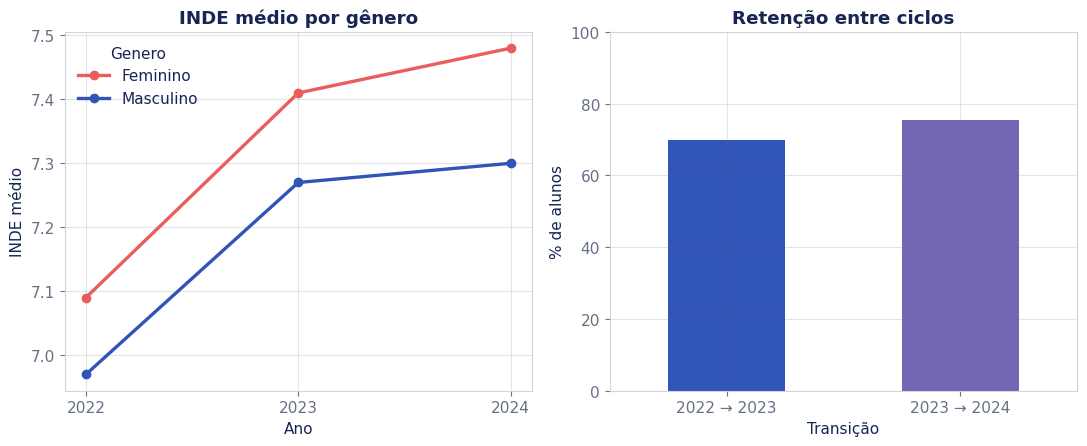

In [17]:
genero_ano = full.pivot_table(index='Genero', columns='Ano', values='INDE', aggfunc='mean').round(2)
print('INDE médio por gênero e ano:')
display(genero_ano)

ra22, ra23, ra24 = (set(full[full['Ano']==a]['RA']) for a in (2022, 2023, 2024))
retencao = pd.Series({
    '2022 → 2023': len(ra22 & ra23) / len(ra22),
    '2023 → 2024': len(ra23 & ra24) / len(ra23),
})
novos = pd.Series({
    'Novos em 2023': len(ra23 - ra22) / len(ra23),
    'Novos em 2024': len(ra24 - ra23) / len(ra24),
})
print('\nRetenção:'); display(retencao.round(3).to_frame('Taxa'))
print('\nParticipação de novos alunos:'); display(novos.round(3).to_frame('Taxa'))

bolsa = full[full['Ano']==2022].groupby('Indicado_bolsa')['INDE'].mean().round(2)
print('\nINDE médio por indicação de bolsa em 2022:'); display(bolsa)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.6))
genero_ano.T.plot(kind='line', marker='o', linewidth=2.4,
                  color=[CORES['coral'], CORES['azul']], ax=ax[0])
ax[0].set_title('INDE médio por gênero'); ax[0].set_xlabel('Ano'); ax[0].set_ylabel('INDE médio')
ax[0].set_xticks([2022, 2023, 2024])
retencao.mul(100).plot(kind='bar', color=[CORES['azul'], CORES['roxo']], ax=ax[1])
ax[1].set_title('Retenção entre ciclos'); ax[1].set_xlabel('Transição'); ax[1].set_ylabel('% de alunos')
ax[1].tick_params(axis='x', rotation=0); ax[1].set_ylim(0, 100)
plt.tight_layout(); plt.show()


**Resposta:** três achados adicionais relevantes:

1. **Gênero:** meninas apresentam INDE ligeiramente superior aos meninos nos três anos (7,09 vs. 6,97 em 2022; 7,48 vs. 7,30 em 2024), uma diferença pequena mas consistente — não é uma alavanca prioritária, mas vale monitorar.
2. **Rotatividade da base:** cerca de **30–40% dos alunos são novos a cada ano** (414/1.014 em 2023; 391/1.156 em 2024) e a retenção ano a ano gira em torno de **70–75%**. Isso reduz o tamanho da coorte longitudinal disponível para medir evolução individual e deve ser considerado na leitura de qualquer indicador "de programa" — parte da mudança nos indicadores agregados reflete composição da turma, não apenas evolução dos mesmos alunos.
3. **Bolsa como sinal de qualidade, não de risco:** alunos indicados a bolsa em 2022 têm INDE médio mais alto (7,41) que os não indicados (6,97) — a indicação parece reconhecer desempenho já consolidado. Sugestão: cruzar a indicação de bolsa com o modelo de risco (Pergunta 9) para verificar se bons candidatos a bolsa em risco de defasagem estão sendo identificados a tempo.

## Conclusão e recomendações

- **A trajetória geral é positiva:** a defasagem severa caiu de 22,2% para 8,0% e mais da metade da base chegou a 2024 em nível adequado.
- **O desempenho acadêmico exige atenção:** o IDA melhorou em 2023, mas recuou em 2024, principalmente nas fases intermediárias.
- **Engajamento é a alavanca mais acionável:** IEG caminha junto com IDA e IPV e pode orientar intervenções no cotidiano.
- **IPS baixo funciona como alerta antecipado:** estudantes no primeiro quartil apresentaram quedas futuras maiores em desempenho e engajamento.
- **Autoavaliação precisa de mediação:** o maior distanciamento entre IAA e IDA aparece justamente entre os alunos de menor desempenho.
- **O modelo atual apoia priorização:** no teste temporal, alcançou ROC-AUC 0,848 e recall 77,6%, com probabilidades calibradas e limiar de 0,4934.
- **A decisão continua humana:** o risco estimado organiza o acompanhamento, mas não substitui a leitura pedagógica e psicossocial.
- **A rotatividade precisa entrar na gestão:** acompanhar coortes por tempo de permanência evita confundir mudança de composição com evolução individual.

> Em conjunto, os resultados são consistentes com evolução positiva do programa, mas não constituem prova causal isolada. O melhor uso da análise é combinar monitoramento contínuo, contexto qualitativo e intervenção oportuna.
